# __Authord__ : Diba Elahi
# Students' Performance

### Task 1 : Data Loading and Preprocessing
### Task 2 : Data Splitting

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from torchvision import transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import sklearn.metrics as metrics
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns

In [12]:
df = pd.read_csv("student_data.csv")

In [13]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [16]:
grade_mean= (df.G1 + df.G2 + df.G3) / 3
df['G_Mean'] = grade_mean
df = df.drop('G1', axis=1)
df = df.drop('G2', axis=1)
df = df.drop('G3', axis=1)
df.head(4)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G_Mean
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.666667
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.333333
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.333333
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.666667


In [17]:
df.isnull().sum() # We do not have null values. 

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G_Mean        0
dtype: int64

In [18]:
ordinal_encoders = [OrdinalEncoder() for _ in range(17)]

In [19]:
# Create a copy of the dataframe
df = df.copy()

In [20]:
categorical_columns = [
    'sex', 'Pstatus', 'school', 'address', 'internet', 'romantic', 
    'Mjob', 'Fjob', 'schoolsup', 'famsup', 'higher', 'paid', 
    'activities', 'nursery', 'guardian', 'reason', 'famsize'
]

In [21]:
for col, encoder in zip(categorical_columns, ordinal_encoders):
    df[col] = encoder.fit_transform(df[col].values.reshape(-1, 1))

In [22]:
X = df.drop('G_Mean', axis=1)
y = df['G_Mean']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.20)

In [24]:
for col in x_train.columns:
    min_val = x_train[col].min()
    max_val = x_train[col].max()
    x_train[col] = (x_train[col] - min_val) / (max_val - min_val)
    x_test[col] = (x_test[col] - min_val) / (max_val - min_val)  # Note: use min and max from x_train

In [25]:
def outlier_removal(data):
    drop_outliers = np.array([])
    for col in data.columns:
        upper_bound = data[col].quantile(0.99)
        lower_bound = data[col].quantile(0.01)

        df_col = data[col]
        indices = df_col[(df_col < lower_bound) | (df_col > upper_bound)].index
        drop_outliers = np.append(drop_outliers, indices)
    return drop_outliers

In [26]:
drop = outlier_removal(x_train)
dropped = np.unique(drop)
x_train.drop(dropped, inplace=True)
y_train.drop(dropped, inplace=True)

In [29]:
y_train.max()

19.333333333333332

In [30]:
y_train.min()

1.3333333333333333

In [31]:
x_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
23,0.0,1.0,0.2,1.0,1.0,1.0,0.50,0.50,0.50,0.50,...,1.0,1.0,0.0,1.00,0.75,0.75,0.25,0.75,1.00,0.000000
296,0.0,0.0,0.8,1.0,0.0,1.0,1.00,1.00,0.25,0.50,...,1.0,1.0,0.0,0.25,0.50,0.75,0.25,0.50,0.25,0.000000
13,0.0,1.0,0.0,1.0,0.0,1.0,1.00,0.75,1.00,0.50,...,1.0,1.0,0.0,1.00,0.75,0.50,0.00,0.25,0.50,0.026667
61,0.0,0.0,0.2,1.0,0.0,1.0,0.25,0.25,0.75,0.75,...,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,1.00,0.080000
351,1.0,1.0,0.4,1.0,0.0,1.0,0.75,0.75,0.25,0.50,...,1.0,1.0,0.0,0.75,1.00,0.75,0.25,0.50,0.50,0.026667


In [32]:
class data:
    def __init__(self, X, y, scale_data=False):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        print(type(self.y))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [33]:
transform = transforms.Compose([transforms.ToTensor(),  transforms.Normalize((0.5,), (0.5,))])
train_dataset = data(x_train.values, y_train.values, scale_data=False)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=10, shuffle=True, num_workers=0)
test_dataset = data(x_test.values, y_test.values, scale_data=False)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=10, shuffle=True, num_workers=0)

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [34]:
data_iter = iter(trainloader)
features, labels = next(data_iter)

### Task 3 :  Model Implementation with PyTorch and 
### Task 4 : Training the MLP Model
### Task 5 : Model Evaluation

As Implementing model and training is in the same package for me and I just run models based on run functions and define different model, these three tasks are combined and I give methodology and process for all of them in my report. 

In [36]:
loss_function = nn.MSELoss() 

In [37]:
def train_model(model, optimizer):
    train_losses, test_losses = [], []
    train_mae_loss, test_mae_loss = [], []
    train_r2_score, test_r2_score = [], []
    
    for epoch in range(0, 30):
        print(f'Starting Epoch {epoch + 1}')
        current_loss = 0
        train_predictions, train_targets = [], []
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(-1, 1)
            
            optimizer.zero_grad()
            outputs = model(features)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            current_loss += (loss.item() * 10)
            train_predictions.extend(outputs.detach().numpy())
            train_targets.extend(labels.detach().numpy())
            

        train_predictions = np.array(train_predictions)
        train_targets = np.array(train_targets)
        train_predictions = torch.tensor(train_predictions).float()
        train_targets = torch.tensor(train_targets).float()
        train_mae = mean_absolute_error(train_targets.detach().numpy(), train_predictions.detach().numpy())
        train_r2 = r2_score(train_targets.detach().numpy(), train_predictions.detach().numpy())
        
        test_loss = 0
        test_predictions, test_targets = [], []
        
        with torch.no_grad():
            model.eval()
            for features, labels in testloader:
                features, labels = features.float(), labels.float()
                labels = labels.reshape(-1, 1)
                
                outputs = model(features)
                loss = loss_function(outputs, labels)
                test_loss += (loss.item() * 10)
                test_predictions.extend(outputs.detach().numpy())
                test_targets.extend(labels.detach().numpy())
           
        test_predictions = np.array(test_predictions)
        test_targets = np.array(test_targets)
        test_predictions = torch.tensor(test_predictions).float()
        test_targets = torch.tensor(test_targets).float()
        test_mae = mean_absolute_error(test_targets.detach().numpy(), test_predictions.detach().numpy())
        test_r2 = r2_score(test_targets.detach().numpy(), test_predictions.detach().numpy())
        
        model.train()
        
        train_losses.append(current_loss / len(train_dataset))
        test_losses.append(test_loss / len(test_dataset))
        
        train_mae_loss.append(train_mae)
        test_mae_loss.append(test_mae)
        
        train_r2_score.append(train_r2)
        test_r2_score.append(test_r2)
        
        print(f'Epoch {epoch + 1} finished',
              f'Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}',
              f'Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}',
              f'Train R2 Score: {train_r2:.4f}, Test R2 Score: {test_r2:.4f}')
    
    print("Training has completed")
    
    return [train_losses, test_losses, train_mae_loss, test_mae_loss, train_r2_score, test_r2_score]


## Simple regression model using ReLU actiovation function

In [38]:
mlp = nn.Sequential(
            nn.Linear(30, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4)

In [39]:
losses = train_model(mlp, optimizer)

Starting Epoch 1
Epoch 1 finished Train Loss: 127.0289, Test Loss: 119.7719 Train MAE: 10.5264, Test MAE: 10.4178 Train R2 Score: -7.4791, Test R2 Score: -11.5648
Starting Epoch 2
Epoch 2 finished Train Loss: 121.9195, Test Loss: 112.8445 Train MAE: 10.3000, Test MAE: 10.1014 Train R2 Score: -7.1560, Test R2 Score: -10.8707
Starting Epoch 3
Epoch 3 finished Train Loss: 112.7232, Test Loss: 97.3251 Train MAE: 9.8009, Test MAE: 9.3201 Train R2 Score: -6.4767, Test R2 Score: -9.2504
Starting Epoch 4
Epoch 4 finished Train Loss: 90.7304, Test Loss: 68.6430 Train MAE: 8.6602, Test MAE: 7.6519 Train R2 Score: -5.0495, Test R2 Score: -6.2354
Starting Epoch 5
Epoch 5 finished Train Loss: 57.3084, Test Loss: 31.9115 Train MAE: 6.6016, Test MAE: 4.7727 Train R2 Score: -2.8170, Test R2 Score: -2.3554
Starting Epoch 6
Epoch 6 finished Train Loss: 25.6487, Test Loss: 11.7346 Train MAE: 4.1824, Test MAE: 2.6460 Train R2 Score: -0.7098, Test R2 Score: -0.2454
Starting Epoch 7
Epoch 7 finished Train L

In [40]:
optimizer_1 = optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-2)
losses_1 = train_model(mlp, optimizer_1)
print(losses_1)

Starting Epoch 1
Epoch 1 finished Train Loss: 60.6645, Test Loss: 25.8141 Train MAE: 6.3330, Test MAE: 4.2637 Train R2 Score: -3.0559, Test R2 Score: -1.7395
Starting Epoch 2
Epoch 2 finished Train Loss: 16.5182, Test Loss: 9.9395 Train MAE: 3.2605, Test MAE: 2.4022 Train R2 Score: -0.1088, Test R2 Score: -0.0478
Starting Epoch 3
Epoch 3 finished Train Loss: 12.7456, Test Loss: 9.5372 Train MAE: 2.8720, Test MAE: 2.4818 Train R2 Score: 0.1437, Test R2 Score: -0.0046
Starting Epoch 4
Epoch 4 finished Train Loss: 11.9186, Test Loss: 15.6743 Train MAE: 2.6726, Test MAE: 3.0758 Train R2 Score: 0.2183, Test R2 Score: -0.6395
Starting Epoch 5
Epoch 5 finished Train Loss: 12.1536, Test Loss: 10.3616 Train MAE: 2.7903, Test MAE: 2.6156 Train R2 Score: 0.1992, Test R2 Score: -0.0893
Starting Epoch 6
Epoch 6 finished Train Loss: 15.7082, Test Loss: 18.2094 Train MAE: 3.2234, Test MAE: 3.3872 Train R2 Score: -0.0383, Test R2 Score: -0.9149
Starting Epoch 7
Epoch 7 finished Train Loss: 13.2880, Te

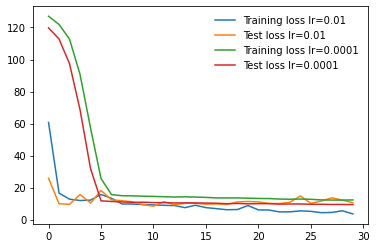

In [43]:
plt.plot(losses_1[0], label = "Training loss lr=0.01")
plt.plot(losses_1[1], label = "Test loss lr=0.01")
plt.plot(losses[0], label = "Training loss lr=0.0001")
plt.plot(losses[1], label = "Test loss lr=0.0001")
plt.legend(frameon = False)

## Simple regression model using Sigmoid activation function

In [44]:
mlp_2 = nn.Sequential(
            nn.Linear(30, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Linear(128, 64),
            nn.Sigmoid(),
            nn.Linear(64, 1)
        )
optimizer_2 = torch.optim.Adam(mlp_2.parameters(), lr=1e-2)

In [45]:
losses_2 = train_model(mlp_2, optimizer_2)
print(losses_2)

Starting Epoch 1
Epoch 1 finished Train Loss: 39.5166, Test Loss: 9.5900 Train MAE: 5.0857, Test MAE: 2.4260 Train R2 Score: -1.6496, Test R2 Score: -0.0057
Starting Epoch 2
Epoch 2 finished Train Loss: 15.4284, Test Loss: 9.4404 Train MAE: 3.1522, Test MAE: 2.4155 Train R2 Score: -0.0267, Test R2 Score: -0.0005
Starting Epoch 3
Epoch 3 finished Train Loss: 15.1314, Test Loss: 9.5806 Train MAE: 3.1480, Test MAE: 2.4208 Train R2 Score: -0.0099, Test R2 Score: -0.0007
Starting Epoch 4
Epoch 4 finished Train Loss: 15.0019, Test Loss: 9.4645 Train MAE: 3.1431, Test MAE: 2.4149 Train R2 Score: -0.0054, Test R2 Score: -0.0003
Starting Epoch 5
Epoch 5 finished Train Loss: 15.2009, Test Loss: 9.6430 Train MAE: 3.1488, Test MAE: 2.4307 Train R2 Score: -0.0105, Test R2 Score: -0.0099
Starting Epoch 6
Epoch 6 finished Train Loss: 15.0291, Test Loss: 9.5982 Train MAE: 3.1587, Test MAE: 2.4225 Train R2 Score: -0.0105, Test R2 Score: -0.0012
Starting Epoch 7
Epoch 7 finished Train Loss: 15.1358, Tes

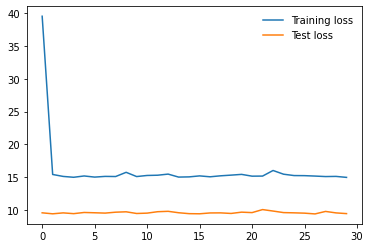

In [46]:
plt.plot(losses_2[0], label = "Training loss")
plt.plot(losses_2[1], label = "Test loss")
plt.legend(frameon = False)

## Simple regression model with LeakyReLU activation function

In [47]:
mlp_3 = nn.Sequential(
            nn.Linear(30, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 1)
        )
optimizer_3 = torch.optim.Adam(mlp_3.parameters(), lr=1e-2)

In [48]:
losses_3 = train_model(mlp_3, optimizer_3)
print(losses_3)

Starting Epoch 1
Epoch 1 finished Train Loss: 31.2746, Test Loss: 19.6287 Train MAE: 4.4760, Test MAE: 3.5952 Train R2 Score: -1.0899, Test R2 Score: -1.0474
Starting Epoch 2
Epoch 2 finished Train Loss: 15.7551, Test Loss: 14.1395 Train MAE: 3.1762, Test MAE: 2.9514 Train R2 Score: -0.0523, Test R2 Score: -0.4789
Starting Epoch 3
Epoch 3 finished Train Loss: 13.7994, Test Loss: 9.4534 Train MAE: 2.9873, Test MAE: 2.4274 Train R2 Score: 0.0937, Test R2 Score: 0.0111
Starting Epoch 4
Epoch 4 finished Train Loss: 11.1257, Test Loss: 9.5784 Train MAE: 2.6538, Test MAE: 2.4541 Train R2 Score: 0.2632, Test R2 Score: -0.0161
Starting Epoch 5
Epoch 5 finished Train Loss: 10.2281, Test Loss: 10.4328 Train MAE: 2.5326, Test MAE: 2.4796 Train R2 Score: 0.3182, Test R2 Score: -0.1014
Starting Epoch 6
Epoch 6 finished Train Loss: 10.8738, Test Loss: 10.1230 Train MAE: 2.6544, Test MAE: 2.4278 Train R2 Score: 0.2701, Test R2 Score: -0.0674
Starting Epoch 7
Epoch 7 finished Train Loss: 9.4800, Test 

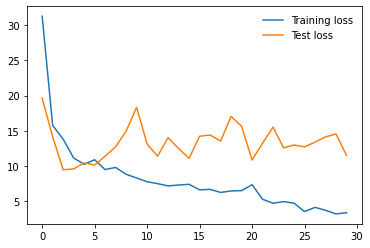

In [49]:
plt.plot(losses_3[0], label = "Training loss")
plt.plot(losses_3[1], label = "Test loss")
plt.legend(frameon = False)

## Now I will test if the depth of the regression model can help for better performance

In [50]:
mlp_4 = nn.Sequential(
                          nn.Linear(30, 512),
                           nn.ReLU(),
                           nn.Linear(512, 256),
                           nn.ReLU(),
                           nn.Linear(256, 128),
                           nn.ReLU(),
                           nn.Linear(128, 64),
                           nn.ReLU(),
                           nn.Linear(64, 1)
                           )
optimizer_4 = torch.optim.Adam(mlp_4.parameters(), lr=1e-4)

In [51]:
losses_4 = train_model(mlp_4, optimizer_4)
print(losses_4)

Starting Epoch 1
Epoch 1 finished Train Loss: 127.7482, Test Loss: 120.1367 Train MAE: 10.5537, Test MAE: 10.4268 Train R2 Score: -7.5177, Test R2 Score: -11.5848
Starting Epoch 2
Epoch 2 finished Train Loss: 119.9089, Test Loss: 103.7302 Train MAE: 10.1714, Test MAE: 9.6566 Train R2 Score: -6.9818, Test R2 Score: -9.9311
Starting Epoch 3
Epoch 3 finished Train Loss: 88.0882, Test Loss: 50.7684 Train MAE: 8.5225, Test MAE: 6.3993 Train R2 Score: -4.9039, Test R2 Score: -4.3577
Starting Epoch 4
Epoch 4 finished Train Loss: 27.6521, Test Loss: 11.4687 Train MAE: 4.2822, Test MAE: 2.6291 Train R2 Score: -0.8595, Test R2 Score: -0.1987
Starting Epoch 5
Epoch 5 finished Train Loss: 15.8942, Test Loss: 10.4604 Train MAE: 3.2699, Test MAE: 2.4803 Train R2 Score: -0.0538, Test R2 Score: -0.1030
Starting Epoch 6
Epoch 6 finished Train Loss: 14.8064, Test Loss: 10.4150 Train MAE: 3.1441, Test MAE: 2.4890 Train R2 Score: 0.0148, Test R2 Score: -0.1037
Starting Epoch 7
Epoch 7 finished Train Loss:

In [52]:
mlp_5 = nn.Sequential(
                          nn.Linear(30, 512),
                           nn.ReLU(),
                           nn.Linear(512, 256),
                           nn.ReLU(),
                           nn.Linear(256, 128),
                           nn.ReLU(),
                           nn.Linear(128, 64),
                           nn.ReLU(),
                           nn.Linear(64, 32),
                           nn.ReLU(),
                           nn.Linear(32, 1)
                           )
optimizer_5 = torch.optim.Adam(mlp_5.parameters(), lr=1e-4)

In [53]:
losses_5 = train_model(mlp_5, optimizer_5)
print(losses_5)

Starting Epoch 1
Epoch 1 finished Train Loss: 130.3938, Test Loss: 122.8411 Train MAE: 10.6360, Test MAE: 10.5709 Train R2 Score: -7.6363, Test R2 Score: -11.9091
Starting Epoch 2
Epoch 2 finished Train Loss: 124.7510, Test Loss: 111.3123 Train MAE: 10.4114, Test MAE: 10.0452 Train R2 Score: -7.3242, Test R2 Score: -10.7527
Starting Epoch 3
Epoch 3 finished Train Loss: 97.7793, Test Loss: 57.2229 Train MAE: 8.9781, Test MAE: 6.8578 Train R2 Score: -5.5145, Test R2 Score: -5.0207
Starting Epoch 4
Epoch 4 finished Train Loss: 29.3615, Test Loss: 13.2155 Train MAE: 4.4064, Test MAE: 2.8784 Train R2 Score: -0.9594, Test R2 Score: -0.3782
Starting Epoch 5
Epoch 5 finished Train Loss: 15.8371, Test Loss: 10.7971 Train MAE: 3.1870, Test MAE: 2.5361 Train R2 Score: -0.0513, Test R2 Score: -0.1276
Starting Epoch 6
Epoch 6 finished Train Loss: 14.7418, Test Loss: 10.4548 Train MAE: 3.1497, Test MAE: 2.5181 Train R2 Score: 0.0139, Test R2 Score: -0.1076
Starting Epoch 7
Epoch 7 finished Train Los

In [54]:
mlp_6 = nn.Sequential(nn.Linear(30, 512),
                           nn.ReLU(),
                           nn.Linear(512, 256),
                           nn.ReLU(),
                           nn.Linear(256, 128),
                           nn.ReLU(),
                           nn.Linear(128, 64),
                           nn.ReLU(),
                           nn.Linear(64, 32),
                           nn.ReLU(),
                           nn.Linear(32, 16),
                           nn.ReLU(),
                           nn.Linear(16, 1),
                           )
optimizer_6 = optim.Adam(mlp_6.parameters(), lr= 1e-4)

In [55]:
losses_6 = train_model(mlp_6, optimizer_6)
print(losses_6)

Starting Epoch 1
Epoch 1 finished Train Loss: 127.1846, Test Loss: 120.8026 Train MAE: 10.5291, Test MAE: 10.4691 Train R2 Score: -7.4839, Test R2 Score: -11.6809
Starting Epoch 2
Epoch 2 finished Train Loss: 124.0077, Test Loss: 112.9402 Train MAE: 10.3631, Test MAE: 10.1258 Train R2 Score: -7.2497, Test R2 Score: -10.9259
Starting Epoch 3
Epoch 3 finished Train Loss: 106.7003, Test Loss: 78.8866 Train MAE: 9.5147, Test MAE: 8.2533 Train R2 Score: -6.1416, Test R2 Score: -7.2593
Starting Epoch 4
Epoch 4 finished Train Loss: 49.3274, Test Loss: 11.8960 Train MAE: 5.9164, Test MAE: 2.6423 Train R2 Score: -2.3263, Test R2 Score: -0.2459
Starting Epoch 5
Epoch 5 finished Train Loss: 16.3826, Test Loss: 10.9699 Train MAE: 3.2631, Test MAE: 2.5623 Train R2 Score: -0.0932, Test R2 Score: -0.1545
Starting Epoch 6
Epoch 6 finished Train Loss: 15.4004, Test Loss: 10.7007 Train MAE: 3.2195, Test MAE: 2.5279 Train R2 Score: -0.0304, Test R2 Score: -0.1327
Starting Epoch 7
Epoch 7 finished Train L

In [56]:
mlp_7 = nn.Sequential(nn.Linear(30, 1024),
                           nn.ReLU(),
                           nn.Linear(1024, 512),
                           nn.ReLU(),
                           nn.Linear(512, 256),
                           nn.ReLU(),
                           nn.Linear(256, 128),
                           nn.ReLU(),
                           nn.Linear(128, 64),
                           nn.ReLU(),
                           nn.Linear(64, 32),
                           nn.ReLU(),
                           nn.Linear(32, 16),
                           nn.ReLU(),
                           nn.Linear(16, 1)
                           )
optimizer_7 = optim.Adam(mlp_7.parameters(), lr=1e-4)

In [57]:
losses_7 = train_model(mlp_7, optimizer_7)
print(losses_7)

Starting Epoch 1
Epoch 1 finished Train Loss: 126.5602, Test Loss: 120.2692 Train MAE: 10.5125, Test MAE: 10.4839 Train R2 Score: -7.4611, Test R2 Score: -11.7141
Starting Epoch 2
Epoch 2 finished Train Loss: 124.0060, Test Loss: 113.8017 Train MAE: 10.4074, Test MAE: 10.1469 Train R2 Score: -7.3101, Test R2 Score: -10.9729
Starting Epoch 3
Epoch 3 finished Train Loss: 92.7214, Test Loss: 36.5594 Train MAE: 8.7356, Test MAE: 5.2255 Train R2 Score: -5.2289, Test R2 Score: -2.8658
Starting Epoch 4
Epoch 4 finished Train Loss: 22.4123, Test Loss: 11.1152 Train MAE: 3.8363, Test MAE: 2.5784 Train R2 Score: -0.4881, Test R2 Score: -0.1693
Starting Epoch 5
Epoch 5 finished Train Loss: 15.5396, Test Loss: 10.9075 Train MAE: 3.2267, Test MAE: 2.5564 Train R2 Score: -0.0333, Test R2 Score: -0.1611
Starting Epoch 6
Epoch 6 finished Train Loss: 14.6896, Test Loss: 11.0476 Train MAE: 3.1299, Test MAE: 2.5507 Train R2 Score: 0.0205, Test R2 Score: -0.1541
Starting Epoch 7
Epoch 7 finished Train Los

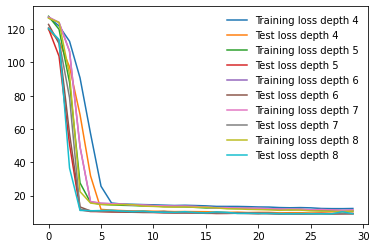

In [58]:
plt.plot(losses[0], label = "Training loss depth 4")
plt.plot(losses[1], label = "Test loss depth 4")
plt.plot(losses_4[0], label = "Training loss depth 5")
plt.plot(losses_4[1], label = "Test loss depth 5")
plt.plot(losses_6[0], label = "Training loss depth 6")
plt.plot(losses_5[1], label = "Test loss depth 6")
plt.plot(losses_6[0], label = "Training loss depth 7")
plt.plot(losses_6[1], label = "Test loss depth 7")
plt.plot(losses_7[0], label = "Training loss depth 8")
plt.plot(losses_7[1], label = "Test loss depth 8")
plt.legend(frameon = False)

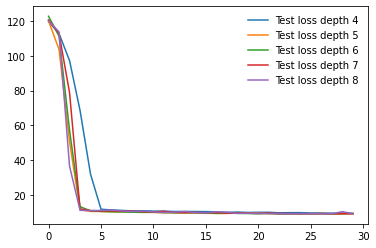

In [59]:
plt.plot(losses[1], label = "Test loss depth 4")
plt.plot(losses_4[1], label = "Test loss depth 5")
plt.plot(losses_5[1], label = "Test loss depth 6")
plt.plot(losses_6[1], label = "Test loss depth 7")
plt.plot(losses_7[1], label = "Test loss depth 8")
plt.legend(frameon = False)

## I will try Dropout and compare its performance with no dropout model 

In [60]:
mlp_dropout = nn.Sequential(nn.Linear(30, 256),
                           nn.ReLU(),
                           nn.Dropout(0.2),
                           nn.Linear(256, 128),
                           nn.ReLU(),
                           nn.Dropout(0.2),
                           nn.Linear(128, 64),
                           nn.ReLU(),
                           nn.Dropout(0.2),
                           nn.Linear(64, 1)
                           )
optimizer_dropout = optim.Adam(mlp_dropout.parameters(), lr=1e-4)

In [61]:
dropout_losses = train_model(mlp_dropout, optimizer_dropout)
print(dropout_losses)

Starting Epoch 1
Epoch 1 finished Train Loss: 126.9758, Test Loss: 118.5056 Train MAE: 10.4827, Test MAE: 10.3640 Train R2 Score: -7.4182, Test R2 Score: -11.4484
Starting Epoch 2
Epoch 2 finished Train Loss: 120.6346, Test Loss: 109.9014 Train MAE: 10.2157, Test MAE: 9.9438 Train R2 Score: -7.0362, Test R2 Score: -10.5375
Starting Epoch 3
Epoch 3 finished Train Loss: 107.2362, Test Loss: 88.6502 Train MAE: 9.5423, Test MAE: 8.8395 Train R2 Score: -6.1385, Test R2 Score: -8.3257
Starting Epoch 4
Epoch 4 finished Train Loss: 78.8179, Test Loss: 52.6177 Train MAE: 7.9824, Test MAE: 6.5284 Train R2 Score: -4.2723, Test R2 Score: -4.5505
Starting Epoch 5
Epoch 5 finished Train Loss: 40.3860, Test Loss: 17.6308 Train MAE: 5.3928, Test MAE: 3.3738 Train R2 Score: -1.7056, Test R2 Score: -0.8677
Starting Epoch 6
Epoch 6 finished Train Loss: 18.7663, Test Loss: 11.3868 Train MAE: 3.5242, Test MAE: 2.6262 Train R2 Score: -0.2421, Test R2 Score: -0.1822
Starting Epoch 7
Epoch 7 finished Train Lo

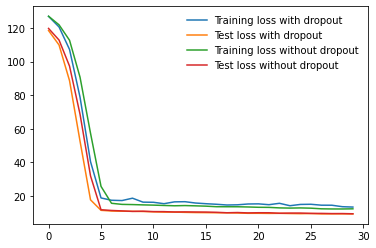

In [62]:
plt.plot(dropout_losses[0], label = "Training loss with dropout")
plt.plot(dropout_losses[1], label = "Test loss with dropout")
plt.plot(losses[0], label = "Training loss without dropout")
plt.plot(losses[1], label = "Test loss without dropout")
plt.legend(frameon = False)

## Batch Normalization

In [63]:
def train_model_batch(model, optimizer):
    train_losses, test_losses = [], []
    train_mae_loss, test_mae_loss = [], []
    train_r2_score, test_r2_score = [], []
    for epoch in range(0,30):
        print(f'Starting Epoch {epoch+1}')
        current_loss = 0
        train_predictions, train_targets = [], []
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(-1, 1)
            optimizer.zero_grad()
            outputs = mlp(features)
            loss = loss_function(outputs, labels)
            loss.backward()

            optimizer.step()

            current_loss += (loss.item()*10)
            train_predictions.extend(outputs.detach().numpy())
            train_targets.extend(labels.detach().numpy())
        
        train_predictions = np.array(train_predictions)
        train_targets = np.array(train_targets)
        train_predictions = torch.tensor(train_predictions).float()
        train_targets = torch.tensor(train_targets).float()
        train_mae = mean_absolute_error(train_targets.detach().numpy(), train_predictions.detach().numpy())
        train_r2 = r2_score(train_targets.detach().numpy(), train_predictions.detach().numpy())
        
        test_loss = 0
        test_predictions, test_targets = [], []
        with torch.no_grad():
            model.eval()
            for features, labels in testloader:
                features, labels = features.float(), labels.float()
                labels = labels.reshape(-1, 1)
                outputs = mlp(features)
                loss = loss_function(outputs, labels)
                test_loss += (loss.item()*10)
                test_predictions.extend(outputs.detach().numpy())
                test_targets.extend(labels.detach().numpy())
                    
                    
                    
                    
        test_predictions = np.array(test_predictions)
        test_targets = np.array(test_targets)
        test_predictions = torch.tensor(test_predictions).float()
        test_targets = torch.tensor(test_targets).float()
        test_mae = mean_absolute_error(test_targets.detach().numpy(), test_predictions.detach().numpy())
        test_r2 = r2_score(test_targets.detach().numpy(), test_predictions.detach().numpy())
        model.train()
        train_losses.append(current_loss/len(train_dataset))
        test_losses.append(test_loss/len(test_dataset))
        print(f'Epoch {epoch + 1} finished',
              f'Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

        
        
    print("Training has completed")
    return [train_losses, test_losses]

In [64]:
mlp_batch = nn.Sequential(nn.Linear(30, 256),
                           nn.ReLU(),
                           nn.BatchNorm1d(256),
                           nn.Linear(256, 128),
                           nn.ReLU(),
                           nn.BatchNorm1d(128),
                           nn.Linear(128, 64),
                           nn.ReLU(),
                           nn.BatchNorm1d(64),
                           nn.Linear(64, 1))
                    
optimizer_batch = optim.Adam(mlp_batch.parameters(), lr=1e-4)

In [65]:
losses_batch = train_model_batch(mlp_batch, optimizer_batch)
print(losses_batch)

Starting Epoch 1
Epoch 1 finished Train Loss: 2.8055, Test Loss: 10.5949
Starting Epoch 2
Epoch 2 finished Train Loss: 2.8087, Test Loss: 10.5024
Starting Epoch 3
Epoch 3 finished Train Loss: 2.8962, Test Loss: 10.5915
Starting Epoch 4
Epoch 4 finished Train Loss: 2.8179, Test Loss: 10.5479
Starting Epoch 5
Epoch 5 finished Train Loss: 2.8016, Test Loss: 10.4927
Starting Epoch 6
Epoch 6 finished Train Loss: 2.7999, Test Loss: 10.5646
Starting Epoch 7
Epoch 7 finished Train Loss: 2.8245, Test Loss: 10.5963
Starting Epoch 8
Epoch 8 finished Train Loss: 2.8276, Test Loss: 10.5528
Starting Epoch 9
Epoch 9 finished Train Loss: 2.8320, Test Loss: 10.6303
Starting Epoch 10
Epoch 10 finished Train Loss: 2.8562, Test Loss: 10.6237
Starting Epoch 11
Epoch 11 finished Train Loss: 2.8222, Test Loss: 10.5674
Starting Epoch 12
Epoch 12 finished Train Loss: 2.8264, Test Loss: 10.5132
Starting Epoch 13
Epoch 13 finished Train Loss: 2.8176, Test Loss: 10.5445
Starting Epoch 14
Epoch 14 finished Train L

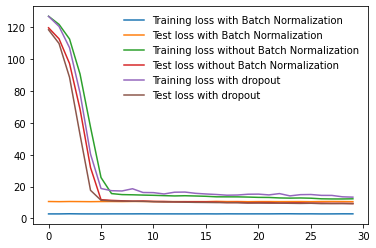

In [66]:
plt.plot(losses_batch[0], label = "Training loss with Batch Normalization")
plt.plot(losses_batch[1], label = "Test loss with Batch Normalization")
plt.plot(losses[0], label = "Training loss without Batch Normalization")
plt.plot(losses[1], label = "Test loss without Batch Normalization")
plt.plot(dropout_losses[0], label = "Training loss with dropout")
plt.plot(dropout_losses[1], label = "Test loss with dropout")
plt.legend(frameon = False)

## L1 and L2 normalization

In [67]:
def train_model_L1(model, optimizer, alpha):
    train_losses, test_losses = [], []
    train_mae_loss, test_mae_loss = [], []
    train_r2_score, test_r2_score = [], []
    
    for epoch in range(0, 30):
        print(f'Starting Epoch {epoch + 1}')
        current_loss = 0
        train_predictions, train_targets = [], []
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(-1, 1)
            optimizer.zero_grad()
            L1_regularization = None
            for i in model.named_parameters():
                if L1_regularization is None:
                      L1_regularization = torch.sum(i[1].__abs__())
                else:
                      L1_regularization += torch.sum(i[1].__abs__())
            outputs = model(features)
            loss = loss_function(outputs, labels)
            loss += alpha * L1_regularization
            loss.backward()
            optimizer.step()
            
            current_loss += (loss.item() * 10)
            train_predictions.extend(outputs.detach().numpy())
            train_targets.extend(labels.detach().numpy())
            

        train_predictions = np.array(train_predictions)
        train_targets = np.array(train_targets)
        train_predictions = torch.tensor(train_predictions).float()
        train_targets = torch.tensor(train_targets).float()
        train_mae = mean_absolute_error(train_targets.detach().numpy(), train_predictions.detach().numpy())
        train_r2 = r2_score(train_targets.detach().numpy(), train_predictions.detach().numpy())
        
        test_loss = 0
        test_predictions, test_targets = [], []
        
        with torch.no_grad():
            model.eval()
            for features, labels in testloader:
                features, labels = features.float(), labels.float()
                labels = labels.reshape(-1, 1)
                
                outputs = model(features)
                loss = loss_function(outputs, labels)
                test_loss += (loss.item() * 10)
                test_predictions.extend(outputs.detach().numpy())
                test_targets.extend(labels.detach().numpy())
           
        test_predictions = np.array(test_predictions)
        test_targets = np.array(test_targets)
        test_predictions = torch.tensor(test_predictions).float()
        test_targets = torch.tensor(test_targets).float()
        test_mae = mean_absolute_error(test_targets.detach().numpy(), test_predictions.detach().numpy())
        test_r2 = r2_score(test_targets.detach().numpy(), test_predictions.detach().numpy())
        
        
        model.train()
        
        train_losses.append(current_loss / len(train_dataset))
        test_losses.append(test_loss / len(test_dataset))
        
        train_mae_loss.append(train_mae)
        test_mae_loss.append(test_mae)
        
        train_r2_score.append(train_r2)
        test_r2_score.append(test_r2)
        
        print(f'Epoch {epoch + 1} finished',
              f'Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}',
              f'Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}',
              f'Train R2 Score: {train_r2:.4f}, Test R2 Score: {test_r2:.4f}')
    
    print("Training has completed")
    
    return [train_losses, test_losses, train_mae_loss, test_mae_loss, train_r2_score, test_r2_score]


In [68]:
l1_losses = train_model_L1(mlp, optimizer, 0.0001)

Starting Epoch 1
Epoch 1 finished Train Loss: 5.2225, Test Loss: 12.8159 Train MAE: 1.6406, Test MAE: 2.7994 Train R2 Score: 0.6841, Test R2 Score: -0.3478
Starting Epoch 2
Epoch 2 finished Train Loss: 4.2879, Test Loss: 12.5319 Train MAE: 1.5335, Test MAE: 2.8275 Train R2 Score: 0.7396, Test R2 Score: -0.3219
Starting Epoch 3
Epoch 3 finished Train Loss: 3.5973, Test Loss: 11.0140 Train MAE: 1.3918, Test MAE: 2.6051 Train R2 Score: 0.7830, Test R2 Score: -0.1596
Starting Epoch 4
Epoch 4 finished Train Loss: 3.6882, Test Loss: 13.1512 Train MAE: 1.4303, Test MAE: 2.7702 Train R2 Score: 0.7753, Test R2 Score: -0.3840
Starting Epoch 5
Epoch 5 finished Train Loss: 3.4555, Test Loss: 12.0541 Train MAE: 1.3601, Test MAE: 2.7100 Train R2 Score: 0.7922, Test R2 Score: -0.2637
Starting Epoch 6
Epoch 6 finished Train Loss: 3.2163, Test Loss: 12.4921 Train MAE: 1.3422, Test MAE: 2.6775 Train R2 Score: 0.8102, Test R2 Score: -0.3076
Starting Epoch 7
Epoch 7 finished Train Loss: 3.5437, Test Loss:

In [69]:
def train_model_L2(model, optimizer, alpha):
    train_losses, test_losses = [], []
    train_mae_loss, test_mae_loss = [], []
    train_r2_score, test_r2_score = [], []
    
    for epoch in range(0, 30):
        print(f'Starting Epoch {epoch + 1}')
        current_loss = 0
        train_predictions, train_targets = [], []
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(-1, 1)
            optimizer.zero_grad()
            L2_regularization = None
            for i in model.named_parameters():
                if L2_regularization is None:
                      L2_regularization = torch.sum(i[1].norm(2) ** 2)
                else:
                      L2_regularization += torch.sum(i[1].norm(2) ** 2)
            outputs = model(features)
            loss = loss_function(outputs, labels)
            loss += alpha * L2_regularization
            loss.backward()
            optimizer.step()
            
            current_loss += (loss.item() * 10)
            train_predictions.extend(outputs.detach().numpy())
            train_targets.extend(labels.detach().numpy())
            

        train_predictions = np.array(train_predictions)
        train_targets = np.array(train_targets)
        train_predictions = torch.tensor(train_predictions).float()
        train_targets = torch.tensor(train_targets).float()
        train_mae = mean_absolute_error(train_targets.detach().numpy(), train_predictions.detach().numpy())
        train_r2 = r2_score(train_targets.detach().numpy(), train_predictions.detach().numpy())
        
        test_loss = 0
        test_predictions, test_targets = [], []
        
        with torch.no_grad():
            model.eval()
            for features, labels in testloader:
                features, labels = features.float(), labels.float()
                labels = labels.reshape(-1, 1)
                
                outputs = model(features)
                loss = loss_function(outputs, labels)
                test_loss += (loss.item() * 10)
                test_predictions.extend(outputs.detach().numpy())
                test_targets.extend(labels.detach().numpy())
           
        test_predictions = np.array(test_predictions)
        test_targets = np.array(test_targets)
        test_predictions = torch.tensor(test_predictions).float()
        test_targets = torch.tensor(test_targets).float()
        test_mae = mean_absolute_error(test_targets.detach().numpy(), test_predictions.detach().numpy())
        test_r2 = r2_score(test_targets.detach().numpy(), test_predictions.detach().numpy())
        
        
        model.train()
        
        train_losses.append(current_loss / len(train_dataset))
        test_losses.append(test_loss / len(test_dataset))
        
        train_mae_loss.append(train_mae)
        test_mae_loss.append(test_mae)
        
        train_r2_score.append(train_r2)
        test_r2_score.append(test_r2)
        
        print(f'Epoch {epoch + 1} finished',
              f'Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}',
              f'Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}',
              f'Train R2 Score: {train_r2:.4f}, Test R2 Score: {test_r2:.4f}')
    
    print("Training has completed")
    
    return [train_losses, test_losses, train_mae_loss, test_mae_loss, train_r2_score, test_r2_score]


In [70]:
l2_losses = train_model_L2(mlp, optimizer, 0.0001)

Starting Epoch 1
Epoch 1 finished Train Loss: 1.2838, Test Loss: 14.4667 Train MAE: 0.8362, Test MAE: 3.0606 Train R2 Score: 0.9216, Test R2 Score: -0.5169
Starting Epoch 2
Epoch 2 finished Train Loss: 1.1440, Test Loss: 15.4887 Train MAE: 0.7882, Test MAE: 3.1065 Train R2 Score: 0.9291, Test R2 Score: -0.6172
Starting Epoch 3
Epoch 3 finished Train Loss: 1.0991, Test Loss: 13.2590 Train MAE: 0.7625, Test MAE: 2.8484 Train R2 Score: 0.9323, Test R2 Score: -0.3978
Starting Epoch 4
Epoch 4 finished Train Loss: 1.5742, Test Loss: 14.4534 Train MAE: 0.9567, Test MAE: 2.9465 Train R2 Score: 0.9012, Test R2 Score: -0.5131
Starting Epoch 5
Epoch 5 finished Train Loss: 1.1043, Test Loss: 13.3220 Train MAE: 0.7755, Test MAE: 2.8591 Train R2 Score: 0.9327, Test R2 Score: -0.3999
Starting Epoch 6
Epoch 6 finished Train Loss: 0.7531, Test Loss: 14.9339 Train MAE: 0.6227, Test MAE: 3.0384 Train R2 Score: 0.9562, Test R2 Score: -0.5717
Starting Epoch 7
Epoch 7 finished Train Loss: 1.5018, Test Loss:

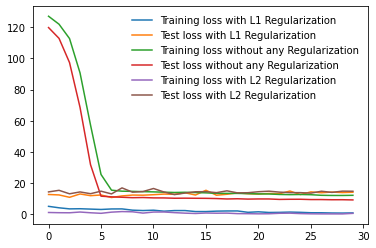

In [71]:
plt.plot(l1_losses[0], label = "Training loss with L1 Regularization")
plt.plot(l1_losses[1], label = "Test loss with L1 Regularization")
plt.plot(losses[0], label = "Training loss without any Regularization")
plt.plot(losses[1], label = "Test loss without any Regularization")
plt.plot(l2_losses[0], label = "Training loss with L2 Regularization")
plt.plot(l2_losses[1], label = "Test loss with L2 Regularization")
plt.legend(frameon = False)

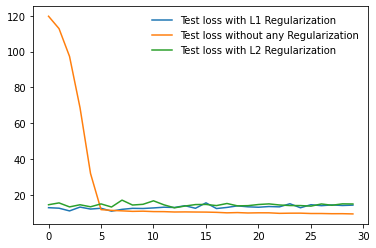

In [72]:
plt.plot(l1_losses[1], label = "Test loss with L1 Regularization")
plt.plot(losses[1], label = "Test loss without any Regularization")
plt.plot(l2_losses[1], label = "Test loss with L2 Regularization")
plt.legend(frameon = False)

In [73]:
l1_losses = train_model_L1(mlp, optimizer, 0.001)
l2_losses = train_model_L2(mlp, optimizer, 0.001)

Starting Epoch 1
Epoch 1 finished Train Loss: 3.1978, Test Loss: 14.9975 Train MAE: 0.6163, Test MAE: 2.9940 Train R2 Score: 0.9600, Test R2 Score: -0.5705
Starting Epoch 2
Epoch 2 finished Train Loss: 3.0013, Test Loss: 14.6487 Train MAE: 0.6382, Test MAE: 2.9867 Train R2 Score: 0.9557, Test R2 Score: -0.5306
Starting Epoch 3
Epoch 3 finished Train Loss: 2.5466, Test Loss: 14.4082 Train MAE: 0.5250, Test MAE: 2.9396 Train R2 Score: 0.9704, Test R2 Score: -0.5089
Starting Epoch 4
Epoch 4 finished Train Loss: 2.3251, Test Loss: 15.1120 Train MAE: 0.5086, Test MAE: 2.9228 Train R2 Score: 0.9716, Test R2 Score: -0.5744
Starting Epoch 5
Epoch 5 finished Train Loss: 2.2740, Test Loss: 15.7452 Train MAE: 0.5173, Test MAE: 3.0987 Train R2 Score: 0.9680, Test R2 Score: -0.6345
Starting Epoch 6
Epoch 6 finished Train Loss: 2.1066, Test Loss: 14.7378 Train MAE: 0.4759, Test MAE: 3.0150 Train R2 Score: 0.9748, Test R2 Score: -0.5639
Starting Epoch 7
Epoch 7 finished Train Loss: 1.9533, Test Loss:

Epoch 24 finished Train Loss: 1.5784, Test Loss: 14.7313 Train MAE: 0.7900, Test MAE: 2.9850 Train R2 Score: 0.9333, Test R2 Score: -0.5531
Starting Epoch 25
Epoch 25 finished Train Loss: 1.2907, Test Loss: 13.9873 Train MAE: 0.6602, Test MAE: 2.9110 Train R2 Score: 0.9525, Test R2 Score: -0.4722
Starting Epoch 26
Epoch 26 finished Train Loss: 1.0009, Test Loss: 14.8964 Train MAE: 0.4923, Test MAE: 3.0327 Train R2 Score: 0.9714, Test R2 Score: -0.5773
Starting Epoch 27
Epoch 27 finished Train Loss: 0.8444, Test Loss: 14.8124 Train MAE: 0.4033, Test MAE: 3.0043 Train R2 Score: 0.9818, Test R2 Score: -0.5587
Starting Epoch 28
Epoch 28 finished Train Loss: 0.9017, Test Loss: 15.5535 Train MAE: 0.4475, Test MAE: 3.1239 Train R2 Score: 0.9777, Test R2 Score: -0.6416
Starting Epoch 29
Epoch 29 finished Train Loss: 0.9962, Test Loss: 14.5672 Train MAE: 0.5193, Test MAE: 2.9657 Train R2 Score: 0.9709, Test R2 Score: -0.5301
Starting Epoch 30
Epoch 30 finished Train Loss: 1.2430, Test Loss: 15.

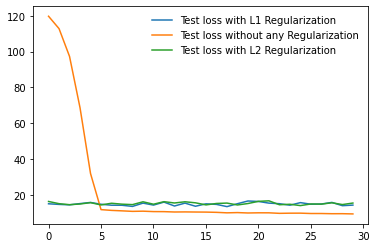

In [74]:
plt.plot(l1_losses[1], label = "Test loss with L1 Regularization")
plt.plot(losses[1], label = "Test loss without any Regularization")
plt.plot(l2_losses[1], label = "Test loss with L2 Regularization")
plt.legend(frameon = False)

In [75]:
def early_stop(test_loss):
    min_loss = np.inf
    diff = 10
    patience = 3
    count = 0
    if test_loss < min_loss:
        min_loss = test_loss
        count = 0
    elif test_loss > (min_loss + diff):
        count += 1
        if count >= patience:
            return True
    return False

In [76]:
def train_model_es(model, optimizer):
    train_losses, test_losses = [], []
    train_mae_loss, test_mae_loss = [], []
    train_r2_score, test_r2_score = [], []
    
    for epoch in range(0, 30):
        print(f'Starting Epoch {epoch + 1}')
        current_loss = 0
        train_predictions, train_targets = [], []
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(-1, 1)
            
            optimizer.zero_grad()
            outputs = model(features)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            current_loss += (loss.item() * 10)
            train_predictions.extend(outputs.detach().numpy())
            train_targets.extend(labels.detach().numpy())
            

        train_predictions = np.array(train_predictions)
        train_targets = np.array(train_targets)
        train_predictions = torch.tensor(train_predictions).float()
        train_targets = torch.tensor(train_targets).float()
        train_mae = mean_absolute_error(train_targets.detach().numpy(), train_predictions.detach().numpy())
        train_r2 = r2_score(train_targets.detach().numpy(), train_predictions.detach().numpy())
        
        test_loss = 0
        test_predictions, test_targets = [], []
        
        with torch.no_grad():
            model.eval()
            for features, labels in testloader:
                features, labels = features.float(), labels.float()
                labels = labels.reshape(-1, 1)
                
                outputs = model(features)
                loss = loss_function(outputs, labels)
                test_loss += (loss.item() * 10)
                test_predictions.extend(outputs.detach().numpy())
                test_targets.extend(labels.detach().numpy())
           
        test_predictions = np.array(test_predictions)
        test_targets = np.array(test_targets)
        test_predictions = torch.tensor(test_predictions).float()
        test_targets = torch.tensor(test_targets).float()
        test_mae = mean_absolute_error(test_targets.detach().numpy(), test_predictions.detach().numpy())
        test_r2 = r2_score(test_targets.detach().numpy(), test_predictions.detach().numpy())
        if early_stop(test_loss):
                print("*************")
                print("Early stopped")
                print("*************")
                break
        model.train()
        
        train_losses.append(current_loss / len(train_dataset))
        test_losses.append(test_loss / len(test_dataset))
        
        train_mae_loss.append(train_mae)
        test_mae_loss.append(test_mae)
        
        train_r2_score.append(train_r2)
        test_r2_score.append(test_r2)
        
        print(f'Epoch {epoch + 1} finished',
              f'Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}',
              f'Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}',
              f'Train R2 Score: {train_r2:.4f}, Test R2 Score: {test_r2:.4f}')
    
    print("Training has completed")
    
    return [train_losses, test_losses, train_mae_loss, test_mae_loss, train_r2_score, test_r2_score]


In [77]:
es_losses = train_model_es(mlp, optimizer)
print(es_losses)

Starting Epoch 1
Epoch 1 finished Train Loss: 1.7274, Test Loss: 12.7223 Train MAE: 1.0254, Test MAE: 2.8073 Train R2 Score: 0.8850, Test R2 Score: -0.3414
Starting Epoch 2
Epoch 2 finished Train Loss: 1.8254, Test Loss: 13.7153 Train MAE: 1.0850, Test MAE: 2.9044 Train R2 Score: 0.8779, Test R2 Score: -0.4399
Starting Epoch 3
Epoch 3 finished Train Loss: 1.5288, Test Loss: 14.8722 Train MAE: 0.9639, Test MAE: 2.9761 Train R2 Score: 0.8981, Test R2 Score: -0.5720
Starting Epoch 4
Epoch 4 finished Train Loss: 0.8596, Test Loss: 13.2070 Train MAE: 0.7292, Test MAE: 2.8692 Train R2 Score: 0.9426, Test R2 Score: -0.4002
Starting Epoch 5
Epoch 5 finished Train Loss: 0.5373, Test Loss: 14.1112 Train MAE: 0.5562, Test MAE: 2.8739 Train R2 Score: 0.9639, Test R2 Score: -0.4919
Starting Epoch 6
Epoch 6 finished Train Loss: 0.9805, Test Loss: 15.8519 Train MAE: 0.7725, Test MAE: 3.0765 Train R2 Score: 0.9340, Test R2 Score: -0.6442
Starting Epoch 7
Epoch 7 finished Train Loss: 0.9115, Test Loss:

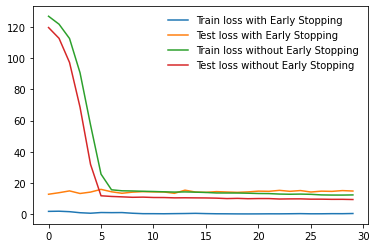

In [78]:
plt.plot(es_losses[0], label = "Train loss with Early Stopping")
plt.plot(es_losses[1], label = "Test loss with Early Stopping")
plt.plot(losses[0], label = "Train loss without Early Stopping")
plt.plot(losses[1], label = "Test loss without Early Stopping")
plt.legend(frameon = False)

### Task 6 : Analysis and Interpretation

In [80]:
fig = plt.figure(figsize=(36,36), dpi = 480)
sns.heatmap(df.corr(), annot = True, fmt = '.2f')

<AxesSubplot:>

In [81]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G_Mean'],
      dtype='object')

In [82]:
for layer in mlp.children():
    if isinstance(layer, nn.Linear):
        print('weight:', layer.weight)
        print('bias:', layer.bias)

weight: Parameter containing:
tensor([[ 2.8933e-01, -6.6610e-02, -3.9902e-01,  ..., -5.3595e-01,
         -5.8609e-02,  2.0535e-01],
        [ 1.0903e-07,  1.1309e-04, -1.2716e-05,  ..., -8.4501e-06,
         -3.8053e-04, -3.6992e-19],
        [-5.1772e-08, -2.6224e-04, -8.8233e-05,  ...,  7.3337e-06,
         -1.3874e-04,  1.9989e-15],
        ...,
        [ 1.7564e-05, -9.7339e-03, -2.0471e-05,  ...,  7.4787e-06,
         -4.2221e-03,  3.7518e-13],
        [-6.0368e-01,  5.4632e-01,  5.5331e-01,  ..., -5.7498e-01,
          8.5128e-01, -1.4911e-01],
        [ 1.5105e-07,  5.4226e-05, -2.8420e-05,  ..., -4.1947e-05,
         -2.2890e-06,  1.3905e-09]], requires_grad=True)
bias: Parameter containing:
tensor([-8.6125e-02, -1.4304e-03,  7.6048e-05, -1.6151e-01, -2.3796e-02,
        -5.3024e-04, -1.1259e-01, -1.8418e-01, -4.7651e-03, -1.9805e-03,
        -2.3185e-03,  6.3456e-02,  4.1879e-02, -2.6881e-03, -3.5403e-03,
        -7.4298e-04, -5.7061e-02, -3.5490e-02, -6.5841e-02, -6.8487e-03